In [40]:
import pandas as pd
from numpy import int8
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# **Frailty Analysis**

In [41]:
df = pd.read_csv('data_raw/frailty.csv')
original_df = pd.read_csv('data_raw/frailty.csv')

height_m = []
weight_kg = []
bmi = []

print('========================== Original Table ====================')
print(original_df)

for i in range(len(df)):
    height_m.append(df['Height'][i] * 0.0254)
    weight_kg.append(df['Weight'][i] * 0.45359237)
    bmi.append(round(weight_kg[i] / (height_m[i] ** 2), 2))

age_bins = [-float('inf'), 29, 45, 60, float('inf')]
age_labels = ['<30', '30-45', '46-60', '>60']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

age_dummies = pd.get_dummies(df['AgeGroup'], prefix='AgeGroup', dtype='int8')

# Only the new changes
new_df = pd.DataFrame({
    'Height (M)': height_m,
    'Weight (kg)': weight_kg,
    'BMI': bmi,
    'AgeGroup': df['AgeGroup'],
})
new_df = pd.concat([new_df, age_dummies], axis=1)
new_df['Frailty'] = df['Frailty']

# Add the columns for combined table
df.insert(1, 'Height (M)', height_m)
df.insert(3, 'Weight (kg)', weight_kg)
df.insert(4, 'BMI', bmi)

final_df = pd.get_dummies(df.drop(columns=['AgeGroup']), columns=['Frailty'], drop_first=True, dtype='int8')
final_df = final_df.rename(columns={final_df.columns[-1]: 'Frailty_binary'})
final_df = pd.concat([final_df, age_dummies], axis=1)

final_new_df = pd.get_dummies(new_df, columns=['Frailty'], drop_first=True, dtype='int8')
final_new_df = final_new_df.rename(columns={final_new_df.columns[-1]: 'Frailty_binary'})

print('\n======================= Combined Table (old + new) =======================')
print(final_df)

print('\n======================== New Table (only changes) ========================')
print(final_new_df)

========================== Original Table ====================
   Height  Weight  Age  Grip strength Frailty
0    65.8     112   30             30       N
1    71.5     136   19             31       N
2    69.4     153   45             29       N
3    68.2     142   22             28       Y
4    67.8     144   29             24       Y
5    68.7     123   50             26       N
6    69.8     141   51             22       Y
7    70.1     136   23             20       Y
8    67.9     112   17             19       N
9    66.8     120   39             31       N

======================= Combined Table (old + new) =======================
   Height  Height (M)  Weight  Weight (kg)    BMI  Age  Grip strength  \
0    65.8     1.67132     112    50.802345  18.19   30             30   
1    71.5     1.81610     136    61.688562  18.70   19             31   
2    69.4     1.76276     153    69.399633  22.33   45             29   
3    68.2     1.73228     142    64.410117  21.46   22         

In [42]:
# Summary Table
means = []
medians = []
st_devs = []
for col in list(final_df.columns):
  means.append(final_df[col].mean())
  medians.append(final_df[col].median())
  st_devs.append(final_df[col].std())

summary_df = pd.DataFrame([means, medians, st_devs], index=['Mean', 'Median', 'St. Dev.'], columns=list(final_df.columns))

summary_df.to_markdown('reports/findings.md')


In [43]:
grip_frailty_corr_matrix = final_df[['Grip strength', 'Frailty_binary']].corr()

with open('reports/grip_vs_frailty_correlation.md', 'w') as file:
    file.write(grip_frailty_corr_matrix.to_markdown())

print(f'Correlation between grip strength and frailty (binary): \n{grip_frailty_corr_matrix}')

Correlation between grip strength and frailty (binary): 
                Grip strength  Frailty_binary
Grip strength        1.000000       -0.475867
Frailty_binary      -0.475867        1.000000


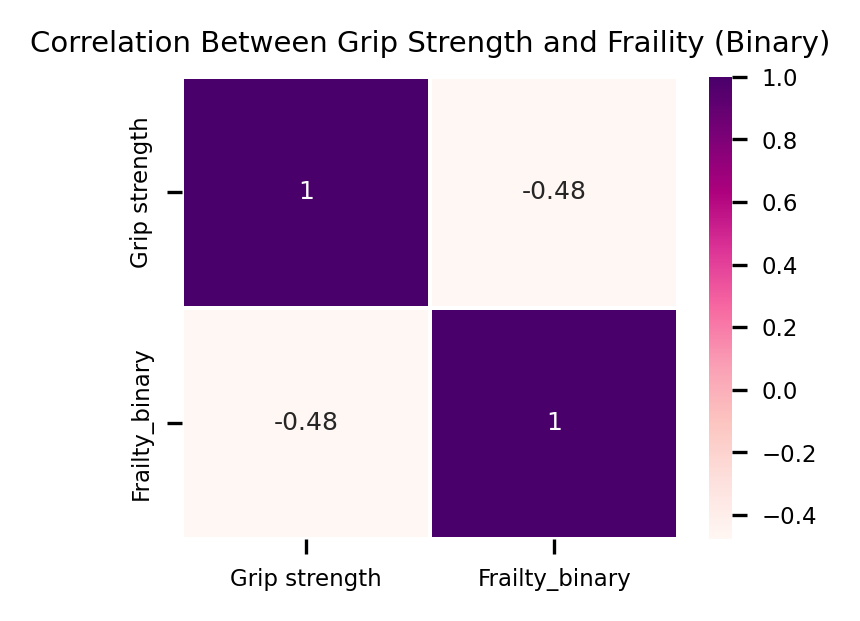

In [44]:
plt.figure(figsize=(800 / 300, 600 / 300), dpi=300)
sns.heatmap(
    grip_frailty_corr_matrix,
    annot=True,
    cmap='RdPu',
    vmax=1,
    linewidths=0.5,
)
plt.title('Correlation Between Grip Strength and Fraility (Binary)')
plt.savefig('reports/figures/grip_vs_frailty_correlation.png', dpi=300)
plt.show()

# **Visualization Tasks**

In [45]:
# Loading the data
local_path = Path('data_raw/StudentsPerformance.csv')
data_url = 'https://app.box.com/s/ji910ez3ycw137rw07xnhielxey7ww41'

source = local_path if local_path.exists() else data_url
student_df = pd.read_csv(source)

In [46]:
# Before moving on, determine if the data has any missing values
missing_summary = pd.DataFrame({
    "missing_count": student_df.isna().sum(),
    "missing_percent": student_df.isna().mean().mul(100).round(1),
})
assert student_df.isna().sum().sum() == 0, "Warning: the data contains missing values"
missing_summary

,missing_count,missing_percent
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0


# Task 1

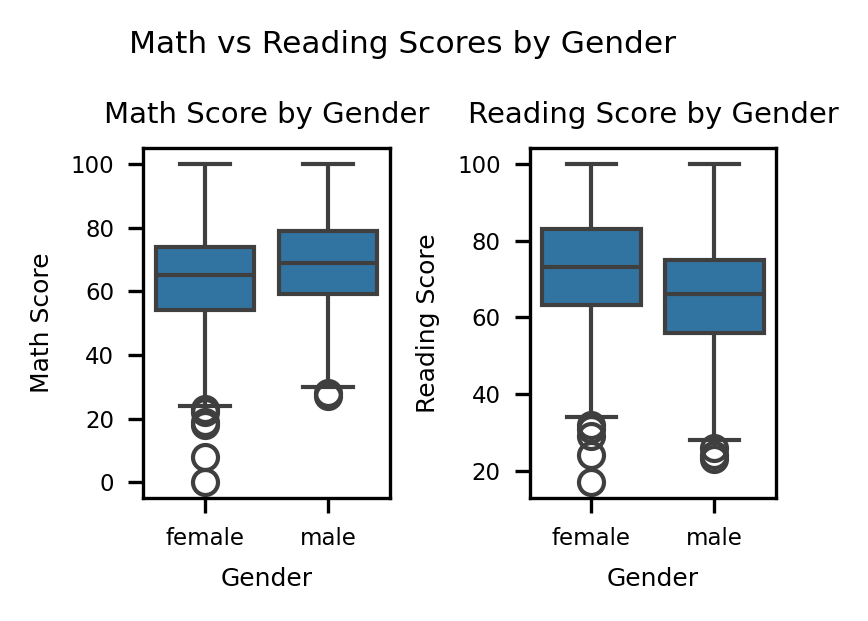

In [47]:
from pathlib import Path

FIG_WIDTH_IN = 800 / 300
FIG_HEIGHT_IN = 600 / 300
FIG_DPI = 300

# Font size changes to make the figures readable
plt.rcParams.update({
    'font.size': 6,
    'axes.titlesize': 7,
    'axes.labelsize': 6,
    'xtick.labelsize': 5.5,
    'ytick.labelsize': 5.5,
    'legend.fontsize': 5,
    'legend.title_fontsize': 5.5,
    'figure.titlesize': 7.5,
})

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN), dpi=FIG_DPI)

sns.boxplot(data=student_df, x='gender', y='math score', ax=axes[0])
axes[0].set_title('Math Score by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Math Score')

sns.boxplot(data=student_df, x='gender', y='reading score', ax=axes[1])
axes[1].set_title('Reading Score by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Reading Score')

fig.suptitle('Math vs Reading Scores by Gender')
plt.tight_layout()
fig.savefig('reports/figures/v1_gender_boxplots.png', dpi=FIG_DPI)
plt.show()

In [48]:
with open('reports/v1_gender_boxplots.md', 'w') as file:
    file.write("The boxplot shows a slight gender gap that's the opposite for the 2 subjects. Female students appear to have a higher median reading score than male students, being approximately 72 and 65 respectively. On the other hand, male students have a slightly higher median math score, being about 62 vs 65. The distributions for female scores have more low-end outliers, while their male counterparts appear more consolidated. Overall, the data shows that the reading scores tend to favor female students.")

The boxplot shows a slight gender gap that's the opposite for the 2 subjects. Female students appear to have a higher median reading score than male students, being approximately 72 and 65 respectively. On the other hand, male students have a slightly higher median math score, being about 62 vs 65. The distributions for female scores have more low-end outliers, while their male counterparts appear more consolidated. Overall, the data shows that the reading scores tend to favor female students.

# Task 2

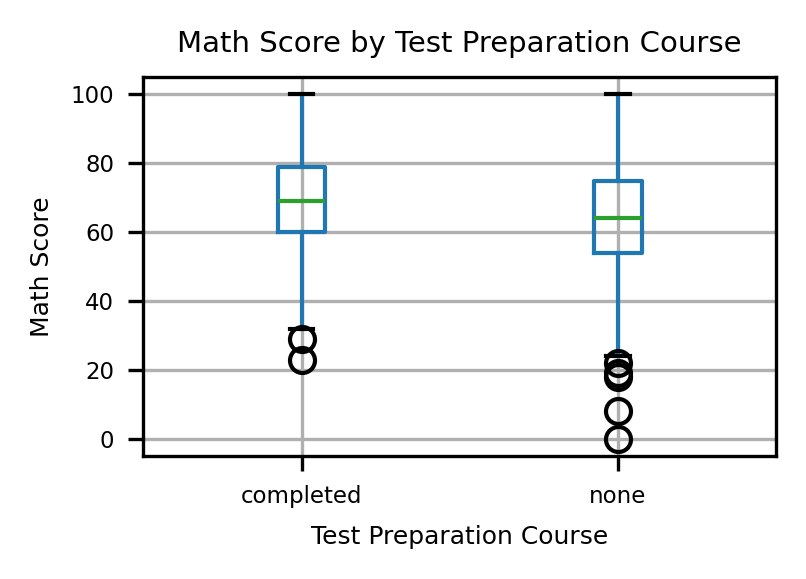

In [49]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN), dpi=FIG_DPI)

student_df.boxplot(column='math score', by='test preparation course', ax=ax)
ax.set_title('Math Score by Test Preparation Course')
ax.set_xlabel('Test Preparation Course')
ax.set_ylabel('Math Score')
ax.get_figure().suptitle('')

plt.tight_layout()
fig.savefig('reports/figures/v2_test_prep_math.png', dpi=FIG_DPI)
plt.show()

In [50]:
with open('reports/v2_test_prep_math.md', 'w') as file:
    file.write("Students who completed the test preparation course have a higher median math score (~69) than those who didn't (about 62), a gap of roughly 7 points. The completed group also shows a narrower range, suggesting consistent performance for students who completed the course. The none group has both a wider spread and more outliers on the lower score end. This pattern suggests that test preparation courses provide a real mild to math scores. However, according to the data, the completion of a test preparation course only has a slight impact on math performance.")

Students who completed the test preparation course have a higher median math score (~69) than those who didn't (about 62), a gap of roughly 7 points. The completed group also shows a narrower range, suggesting consistent performance for students who completed the course. The none group has both a wider spread and more outliers on the lower score end. This pattern suggests that test preparation courses provide a real mild to math scores. However, according to the data, the completion of a test preparation course only has a slight impact on math performance.

# Task 3

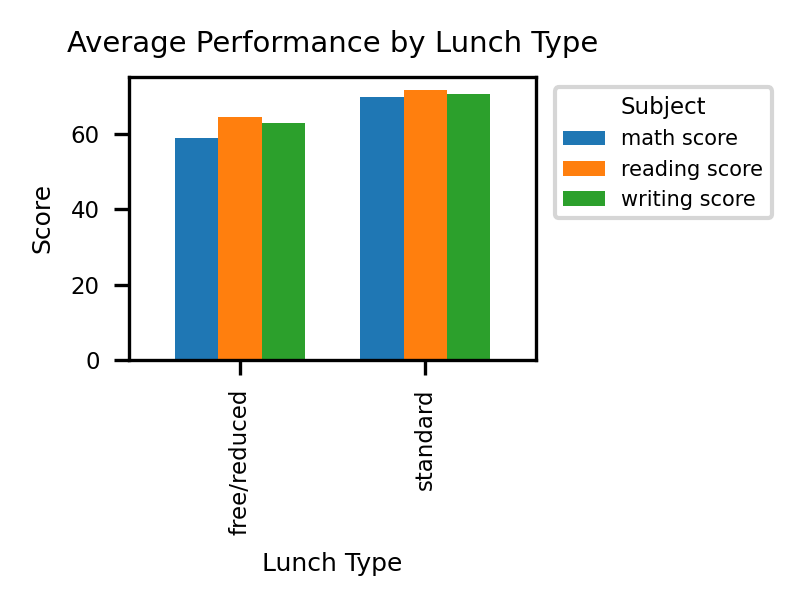

In [51]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN), dpi=FIG_DPI)

student_df_group = student_df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()
student_df_group.plot.bar(ax=ax, width=0.7)

ax.set_title('Average Performance by Lunch Type')
ax.set_xlabel('Lunch Type')
ax.set_ylabel('Score')
ax.legend(title='Subject', loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
fig.savefig('reports/figures/v3_lunch_performance.png', dpi=FIG_DPI)
plt.show()

In [52]:
with open('reports/v3_lunch_performance.md', 'w') as file:
    file.write("Looking at the chart, students who recieve a standard lunch perform better than free/reduced lunch students across all 3 subjects. The score gaps between subjects is consistent among the 3 which suggests that a student's lunch type is associated with better performance in general rather than being tied to one specific subject. It appears that reading and writing have a slightly larger gap than math, which may show some tie between lunch type and literacy skills. However, a student's lunch type is heavily tied to their economic status, which may bring in other factors that could impact their performance such as tutoring, home life, etc. Overall, there does seem to be a tie between lunch type and performance, but it can't be deemed the only factor.")

Looking at the chart, students who recieve a standard lunch perform better than free/reduced lunch students across all 3 subjects. The score gaps between subjects is consistent among the 3 which suggests that a student's lunch type is associated with better performance in general rather than being tied to one specific subject. It appears that reading and writing have a slightly larger gap than math, which may show some tie between lunch type and literacy skills. However, a student's lunch type is heavily tied to their economic status, which may bring in other factors that could impact their performance such as tutoring, home life, etc. Overall, there does seem to be a tie between lunch type and performance, but it can't be deemed the only factor.

# Task 4

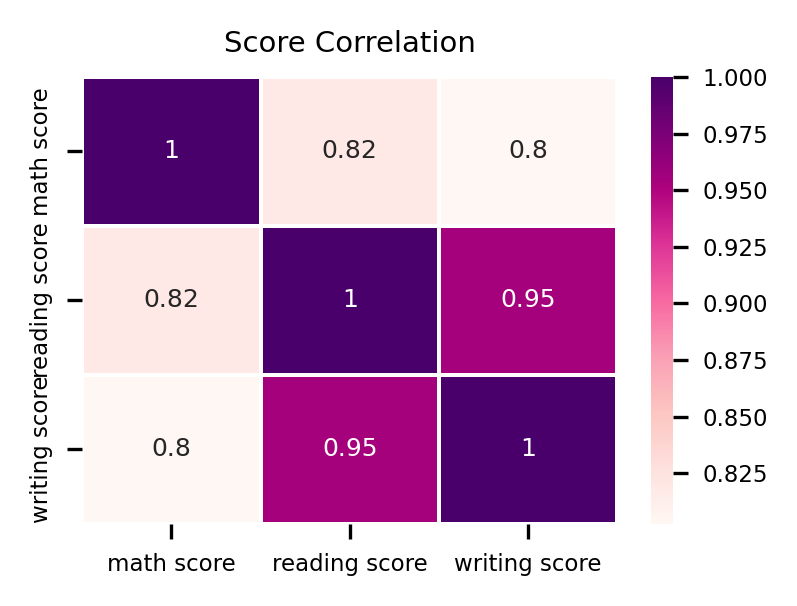

In [53]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN), dpi=FIG_DPI)

corr_matrix = student_df[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdPu', vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Score Correlation')

plt.tight_layout()
fig.savefig('reports/figures/v4_score_correlation.png', dpi=FIG_DPI)
plt.show()

In [54]:
with open('reports/v4_score_correlation.md', 'w') as file:
    file.write("All 3 subjects are strongly positively correlated, with reading and writing having the strongest relationship (0.95). Math correlates decently with reading (0.82) and writing (0.80), but is weaker than the reading-writing relationship. Logically, this makes sense given that reading and writing are language/literacy based skills that have many overlapping abilities. On the other hand, math often relies on a more unique and distinct skill set. Given that all subject correlations are above (or equal to) 0.80, it looks like an overall academic performance factor can be seen across the students, meaning that if a student does well in 1 subject, they're likely to do well in all 3.")

All 3 subjects are strongly positively correlated, with reading and writing having the strongest relationship (0.95). Math correlates decently with reading (0.82) and writing (0.80), but is weaker than the reading-writing relationship. Logically, this makes sense given that reading and writing are language/literacy based skills that have many overlapping abilities. On the other hand, math often relies on a more unique and distinct skill set. Given that all subject correlations are above (or equal to) 0.80, it looks like an overall academic performance factor can be seen across the students, meaning that if a student does well in 1 subject, they're likely to do well in all 3.

# Task 5

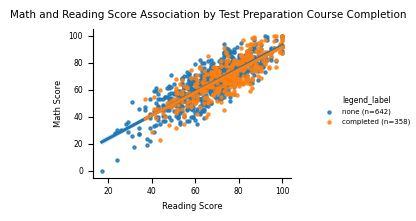

In [55]:
counts = student_df['test preparation course'].value_counts()
student_df['legend_label'] = student_df['test preparation course'].map(
    lambda x: f'{x} (n={counts[x]})'
)

g = sns.lmplot(
    data=student_df,
    x='reading score',
    y='math score',
    hue='legend_label',
    height=FIG_HEIGHT_IN,
    aspect=FIG_WIDTH_IN / FIG_HEIGHT_IN,
    scatter_kws={'s': 5},
)
g.figure.suptitle('Math and Reading Score Association by Test Preparation Course Completion', y=1.05)
g.set_axis_labels('Reading Score', 'Math Score')

g.savefig('reports/figures/v5_math_reading_trend.png', dpi=FIG_DPI)
plt.show()

In [56]:
with open('reports/v5_math_reading_trend.md', 'w') as file:
    file.write("Overall, math and readying scores are strongly positively associated, with both test groups showing an upward trend. The slope of the 2 best-fit lines are very close, showing that the relationship between reading and math scores is similar independent of test preparation completion. This indicates that students who read well also tend to do well in math, regardless of whether they took the preparation course. The main difference between the none vs completed data is the intercept. The completed group is consistently above its none group counterpart, meaning that for any given reading score, students who completed the prep are likely going to score higher in math. This suggests that the completion of a test preparation course provides uniform boost across the reading score range rather than helping weaker or stronger readers disproportionately.")

Overall, math and readying scores are strongly positively associated, with both test groups showing an upward trend. The slope of the 2 best-fit lines are very close, showing that the relationship between reading and math scores is similar independent of test preparation completion. This indicates that students who read well also tend to do well in math, regardless of whether they took the preparation course. The main difference between the none vs completed data is the intercept. The completed group is consistently above its none group counterpart, meaning that for any given reading score, students who completed the prep are likely going to score higher in math. This suggests that the completion of a test preparation course provides uniform boost across the reading score range rather than helping weaker or stronger readers disproportionately.